# Selección de características con un algoritmo genético
**Actividad 02 | Ejemplo nuevo que completa los tres casos solicitados.**

Objetivo: elegir un subconjunto de las 13 variables de Wine para una regresión logística.
El clasificador y sus hiperparámetros se mantienen fijos: lo que evoluciona es una máscara binaria.
Ejecuta todas las celdas en orden en Google Colab (CPU). No requiere subir datos ni otros archivos.


In [1]:
# Google Colab incluye estas bibliotecas. Si hace falta, descomenta y ejecuta:
# %pip install numpy scikit-learn matplotlib


## 1. Datos y separación de prueba
Wine tiene 178 observaciones y 3 clases. Reservamos 20 % para prueba.
La búsqueda y el escalado usan exclusivamente el conjunto de desarrollo y sus pliegues de CV.


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

SEED = 42
data = load_wine()
X, y = data.data, data.target
idx_dev, idx_test = train_test_split(np.arange(len(y)), test_size=0.20, stratify=y, random_state=SEED)
X_dev, y_dev = X[idx_dev], y[idx_dev]
X_test, y_test = X[idx_test], y[idx_test]
assert set(idx_dev).isdisjoint(idx_test)
N_FEATURES = X.shape[1]
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
PENALIZACION = 0.02
def crear_modelo():
    return make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=2000, random_state=SEED))
print(f'Wine: {len(y)} muestras, {N_FEATURES} variables, 3 clases')
print(f'Desarrollo: {len(y_dev)} | Test reservado: {len(y_test)}')


Wine: 178 muestras, 13 variables, 3 clases
Desarrollo: 142 | Test reservado: 36


## 2. Cromosoma, inicialización y aptitud
Un vector de 13 bits indica qué variables incluir: 1 = usar; 0 = descartar.
Si una máscara queda vacía, activamos un bit al azar (reparación).
**fitness = exactitud CV - 0.02 × (variables seleccionadas / 13)**.
La penalización, fijada antes de ejecutar, favorece soluciones compactas.
El fitness penalizado no es una exactitud; se reportan ambos valores por separado.
`StandardScaler` está dentro del pipeline, así se ajusta únicamente en el entrenamiento de cada pliegue.


In [3]:
rng = random.Random(SEED)
cache = {}
def reparar(bits):
    bits = list(bits)
    if not any(bits):
        bits[rng.randrange(N_FEATURES)] = 1
    return bits

def crear_individuo():
    return reparar([rng.randint(0, 1) for _ in range(N_FEATURES)])

def evaluar(bits):
    key = tuple(bits)
    if key not in cache:
        mask = np.array(bits, dtype=bool)
        assert mask.any() and len(mask) == N_FEATURES
        scores = cross_val_score(crear_modelo(), X_dev[:, mask], y_dev, cv=CV,
                                 scoring='accuracy', error_score='raise')
        exactitud = float(scores.mean())
        cache[key] = {'cv': exactitud, 'fitness': exactitud - PENALIZACION * int(mask.sum()) / N_FEATURES}
    return cache[key]


## 3. Selección, cruzamiento y mutación
Torneo de 3 individuos; gana la mayor aptitud. Cruce de un punto con probabilidad 0.8.
Mutación por bit con probabilidad 1/13 (un cambio esperado por cromosoma).
Se reparan máscaras vacías después de cruzar o mutar. Se conservan 2 élites.


In [4]:
def seleccionar(poblacion):
    return max(rng.sample(poblacion, 3), key=lambda x: evaluar(x)['fitness'])[:]

def cruzar(a, b, tasa=0.8):
    if rng.random() >= tasa:
        return a[:], b[:]
    punto = rng.randint(1, N_FEATURES - 1)
    return reparar(a[:punto] + b[punto:]), reparar(b[:punto] + a[punto:])

def mutar(bits, tasa=1 / N_FEATURES):
    return reparar([1 - bit if rng.random() < tasa else bit for bit in bits])


## 4. Ciclo completo y terminación
Población de 16 candidatos, 10 generaciones y 2 élites. La población inicial incluye
una máscara con todas las variables como referencia y 15 máscaras aleatorias.
El historial registra la población inicial y cada población resultante, incluida la última.


In [5]:
def ejecutar_ag(tamano=16, generaciones=10, elite=2):
    assert tamano >= 3 and 0 < elite < tamano and generaciones >= 0
    rng.seed(SEED)
    cache.clear()
    poblacion = [[1] * N_FEATURES] + [crear_individuo() for _ in range(tamano - 1)]
    historial = []
    for gen in range(generaciones + 1):
        poblacion.sort(key=lambda b: evaluar(b)['fitness'], reverse=True)
        aptitudes = [evaluar(b)['fitness'] for b in poblacion]
        ganador = poblacion[0]
        historial.append({'generacion': gen, 'mejor': max(aptitudes), 'media': float(np.mean(aptitudes)),
                          'peor': min(aptitudes), 'variables': sum(ganador)})
        print(f"Generación {gen:02d}: fitness={max(aptitudes):.4f}, CV={evaluar(ganador)['cv']:.4f}, variables={sum(ganador)}")
        if gen == generaciones:
            break
        nueva = [b[:] for b in poblacion[:elite]]
        while len(nueva) < tamano:
            a, b = cruzar(seleccionar(poblacion), seleccionar(poblacion))
            nueva.extend([mutar(a), mutar(b)])
        poblacion = nueva[:tamano]
    return poblacion[0][:], historial

mejor, historial = ejecutar_ag()
assert all(historial[i+1]['mejor'] >= historial[i]['mejor'] - 1e-12 for i in range(len(historial)-1))
assert all(len(k) == N_FEATURES and set(k) <= {0, 1} and any(k) for k in cache)


Generación 00: fitness=0.9571, CV=0.9648, variables=5


Generación 01: fitness=0.9753, CV=0.9861, variables=7


Generación 02: fitness=0.9823, CV=0.9931, variables=7


Generación 03: fitness=0.9823, CV=0.9931, variables=7


Generación 04: fitness=0.9823, CV=0.9931, variables=7


...

Generación 06: fitness=0.9862, CV=1.0000, variables=9


Generación 07: fitness=0.9862, CV=1.0000, variables=9


Generación 08: fitness=0.9862, CV=1.0000, variables=9


Generación 09: fitness=0.9862, CV=1.0000, variables=9


Generación 10: fitness=0.9892, CV=1.0000, variables=7


## 5. Evolución y variables elegidas


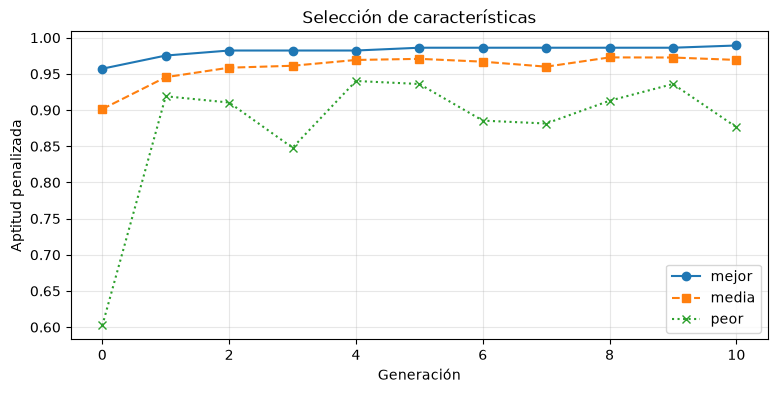

Máscara ganadora: [1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1]
Variables elegidas: ['alcohol', 'ash', 'alcalinity_of_ash', 'flavanoids', 'color_intensity', 'hue', 'proline']


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for campo, estilo in [('mejor', 'o-'), ('media', 's--'), ('peor', 'x:')]:
    ax.plot([h['generacion'] for h in historial], [h[campo] for h in historial], estilo, label=campo)
ax.set(xlabel='Generación', ylabel='Aptitud penalizada', title='Selección de características')
ax.legend(); ax.grid(alpha=0.3)
plt.show()
mask = np.array(mejor, dtype=bool)
seleccionadas = np.array(data.feature_names)[mask].tolist()
print('Máscara ganadora:', mejor)
print('Variables elegidas:', seleccionadas)


## 6. Evaluación final contra todas las variables
Una vez terminada la selección, entrenamos ambos modelos en todo desarrollo y evaluamos
en el mismo test reservado. No se modifica la máscara tras ver esos resultados.


In [7]:
referencia_cv = evaluar([1] * N_FEATURES)['cv']
referencia = crear_modelo().fit(X_dev, y_dev)
modelo_final = crear_modelo().fit(X_dev[:, mask], y_dev)
base_test = float(referencia.score(X_test, y_test))
ag_test = float(modelo_final.score(X_test[:, mask], y_test))
resultado = {'ejemplo': 'Selección de características', 'semilla': SEED,
             'n_desarrollo': len(y_dev), 'n_test': len(y_test), 'referencia_cv': referencia_cv,
             'mejor_cv': evaluar(mejor)['cv'], 'fitness': evaluar(mejor)['fitness'],
             'penalizacion': PENALIZACION, 'referencia_test': base_test, 'ag_test': ag_test,
             'n_variables': int(mask.sum()), 'variables': seleccionadas, 'mascara': mejor,
             'evaluaciones_unicas': len(cache), 'historial': historial}
print(f'Todas las variables: CV={referencia_cv:.2%}, test={base_test:.2%}')
print(f'Selección AG: CV={resultado["mejor_cv"]:.2%}, test={ag_test:.2%}, {sum(mejor)}/{N_FEATURES} variables')


Todas las variables: CV=97.19%, test=97.22%
Selección AG: CV=100.00%, test=97.22%, 7/13 variables


## 7. Exportar resultados


In [8]:
import json, platform
from pathlib import Path
import sklearn, matplotlib
resultado['versiones'] = {'python': platform.python_version(), 'numpy': np.__version__,
                         'scikit_learn': sklearn.__version__, 'matplotlib': matplotlib.__version__}
Path('resultados').mkdir(exist_ok=True)
ruta = Path('resultados/seleccion_caracteristicas.json')
ruta.write_text(json.dumps(resultado, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(resultado, ensure_ascii=False, indent=2))
print('Resultado guardado en:', ruta)


{
  "ejemplo": "Selección de características",
  "semilla": 42,
  "n_desarrollo": 142,
  "n_test": 36,
  "referencia_cv": 0.9719267139479907,
  "mejor_cv": 1.0,
  "fitness": 0.9892307692307692,
  "penalizacion": 0.02,
  "referencia_test": 0.9722222222222222,
  "ag_test": 0.9722222222222222,
  "n_variables": 7,
  "variables": [
    "alcohol",
    "ash",
    "alcalinity_of_ash",
    "flavanoids",
    "color_intensity",
    "hue",
    "proline"
  ],
  "mascara": [
    1,
    0,
    1,
    1,
    0,
    0,
    1,
    0,
    0,
    1,
    1,
    0,
    1
  ],
  "evaluaciones_unicas": 108,
  "historial": [
    {
      "generacion": 0,
      "mejor": 0.9571422076741226,
      "media": 0.9013980666939443,
      "peor": 0.6022717766866703,
      "variables": 5
    },
    {
      "generacion": 1,
      "mejor": 0.9753418803418804,
      "media": 0.9454243385160939,
      "peor": 0.9190475541007457,
      "variables": 7
    },
    {
      "generacion": 2,
      "mejor": 0.9822863247863247,
      

## Interpretación y defensa oral
- Explica cada bit del cromosoma y cómo se repara una máscara vacía.
- Justifica la penalización: equilibrar exactitud de validación y número de variables.
- Sigue un torneo, un cruce y una mutación en el código.
- Compara referencia y ganador tanto en CV como en prueba. Menos variables no garantiza mayor exactitud.
- Son datos pequeños y una sola semilla; se encuentra una buena solución observada, no se demuestra el óptimo.

Fuentes: [Wine](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html)
y [validación cruzada](https://scikit-learn.org/stable/modules/cross_validation.html).
